In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import collections
import pandas as pd
import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo
import seaborn as sns

# settings
%config InlineBackend.figure_format = 'retina'
dpath0='/Users/dervlamk/OneDrive/research'
dpath1=f'{dpath0}/topo_nam'

In [2]:
lr_infile=f'{dpath1}/data/hrmip.nam.bias.lr.2.csv' # has the extra CMCC model removed so names match up with hr
lowres = pd.read_csv(lr_infile)

hr_infile=f'{dpath1}/data/hrmip.nam.bias.hr.csv'
highres = pd.read_csv(hr_infile)

In [3]:
#=== make variable arrays
names = lowres.iloc[0].astype(str).tolist()

# low res
lr_res  = lowres.iloc[1].to_numpy(dtype=float)
lr_bias = lowres.iloc[3].to_numpy(dtype=float)

# high res
hr_res  = highres.iloc[1].to_numpy(dtype=float)
hr_bias = highres.iloc[3].to_numpy(dtype=float)

markers should probably have error bars or be a box plot?

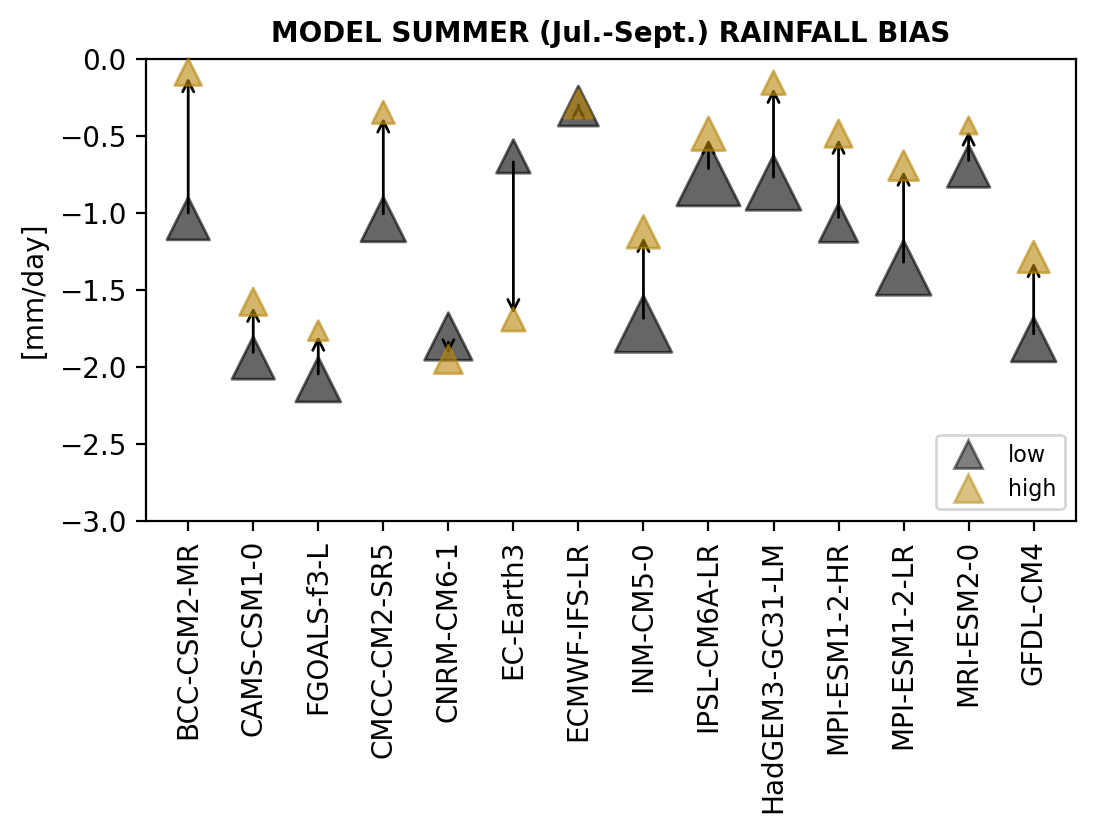

In [46]:
text_kw={'size': 'medium', 'weight': 'bold', 'color': 'black'}
legend_kw={'loc':4,'fontsize':8, 'labelcolor':'k', 'frameon':True}
arrow_kw={'arrowstyle':'->', 'color':'k', 'linewidth':1, 'shrinkA':2, 'shrinkB':2}

fig = plt.figure(figsize=(6, 3))
ax = plt.subplot(111)

ax.set_title('MODEL SUMMER (Jul.-Sept.) RAINFALL BIAS', **text_kw)

ax.scatter(names, lr_bias,
           s=(1/lr_res)*75000, marker='^',
           c='k', edgecolors='k',
           alpha=.6, clip_on=False, zorder=100,
           label='lowres') 

ax.scatter(names, hr_bias,
           s=(1/hr_res)*75000, marker='^',
           c='darkgoldenrod', edgecolors='darkgoldenrod',
           alpha=.6, clip_on=False, zorder=100,
           label='highres') 

for x, y1, y2 in zip(names, lr_bias, hr_bias):
    ax.annotate("", xy=(x, y2), xytext=(x, y1), arrowprops=arrow_kw, label='change direction')

ax.set(ylabel='[mm/day]', ylim=[-3,0])
ax.tick_params(axis='x', rotation=90)

# Create fixed-size legend markers manually
legend_handles = [
    Line2D([0], [0], marker='^', color='w', alpha=.5, markeredgecolor='k', markerfacecolor='k', markersize=10, label='low'),
    Line2D([0], [0], marker='^', color='w', alpha=.5, markeredgecolor='darkgoldenrod', markerfacecolor='darkgoldenrod', markersize=10, label='high')
]
ax.legend(handles=legend_handles, **legend_kw)